In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

import mysql.connector


In [2]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 25   # Increased for accuracy

BASE_DIR = r"C:\Users\Dell\OneDrive\Desktop\plant_disease_dataset"
DATASET_DIR = BASE_DIR + r"\New_Plant_Disease_Dataset"

TRAIN_DIR = DATASET_DIR + r"\train"
VAL_DIR   = DATASET_DIR + r"\valid"
TEST_DIR  = BASE_DIR + r"\test\test"

print("Train exists:", os.path.exists(TRAIN_DIR))
print("Validation exists:", os.path.exists(VAL_DIR))
print("Test exists:", os.path.exists(TEST_DIR))


Train exists: True
Validation exists: True
Test exists: True


In [3]:
train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=30,
    zoom_range=0.2,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    fill_mode="nearest"
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)


In [4]:
train_data = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical"
)

val_data = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

class_labels = list(train_data.class_indices.keys())
num_classes = len(class_labels)

print("Total classes:", num_classes)


Found 2040 images belonging to 38 classes.
Found 1140 images belonging to 38 classes.
Total classes: 38


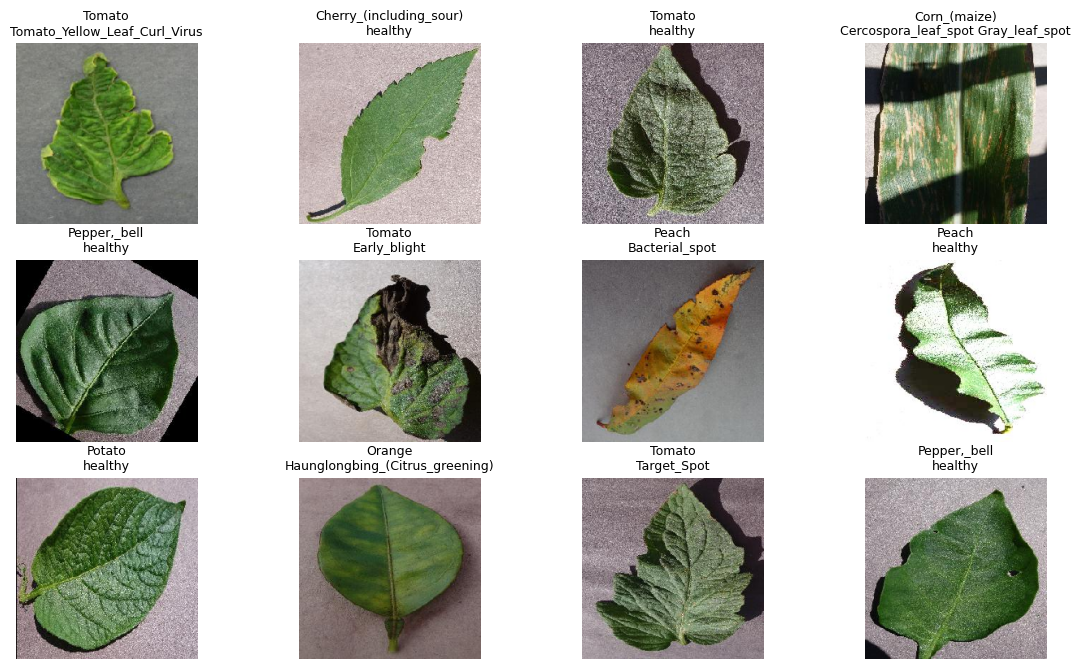

In [5]:
image_label_pairs = []

for class_name in os.listdir(TRAIN_DIR):
    class_path = os.path.join(TRAIN_DIR, class_name)
    if os.path.isdir(class_path):
        for img in os.listdir(class_path):
            image_label_pairs.append((os.path.join(class_path, img), class_name))

samples = random.sample(image_label_pairs, 12)

plt.figure(figsize=(14, 8))
for i, (img_path, label) in enumerate(samples):
    img = load_img(img_path, target_size=(IMG_SIZE, IMG_SIZE))
    plt.subplot(3, 4, i + 1)
    plt.imshow(img)
    plt.title(label.replace("___", "\n"), fontsize=9)
    plt.axis("off")

plt.show()


In [6]:
base_model = EfficientNetB0(
    weights="imagenet",
    include_top=False,
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)

base_model.trainable = False   # First phase

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(512, activation="relu")(x)
x = Dropout(0.6)(x)
x = Dense(256, activation="relu")(x)
x = Dropout(0.4)(x)
output = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=base_model.input, outputs=output)


In [7]:
model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 input_1 (InputLayer)           [(None, 224, 224, 3  0           []                               
                                )]                                                                
                                                                                                  
 rescaling (Rescaling)          (None, 224, 224, 3)  0           ['input_1[0][0]']                
                                                                                                  
 normalization (Normalization)  (None, 224, 224, 3)  7           ['rescaling[0][0]']              
                                                                                                  
 rescaling_1 (Rescaling)        (None, 224, 224, 3)  0           ['normalization[0][0]']      

In [8]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=EPOCHS
)


Epoch 1/25
64/64 [==============================] - 225s 3s/step - loss: 3.6561 - accuracy: 0.0574 - val_loss: 3.4284 - val_accuracy: 0.1693
Epoch 2/25
64/64 [==============================] - 208s 3s/step - loss: 3.4016 - accuracy: 0.1123 - val_loss: 3.2007 - val_accuracy: 0.2807
Epoch 3/25
64/64 [==============================] - 209s 3s/step - loss: 3.1305 - accuracy: 0.2074 - val_loss: 2.9114 - val_accuracy: 0.3930
Epoch 4/25
64/64 [==============================] - 210s 3s/step - loss: 2.8822 - accuracy: 0.2549 - val_loss: 2.6134 - val_accuracy: 0.4596
Epoch 5/25
64/64 [==============================] - 207s 3s/step - loss: 2.6274 - accuracy: 0.3054 - val_loss: 2.3361 - val_accuracy: 0.5167
Epoch 6/25
64/64 [==============================] - 208s 3s/step - loss: 2.3809 - accuracy: 0.3647 - val_loss: 2.0650 - val_accuracy: 0.5684
Epoch 7/25
64/64 [==============================] - 209s 3s/step - loss: 2.1264 - accuracy: 0.4265 - val_loss: 1.8098 - val_accuracy: 0.6272
Epoch 8/25
64

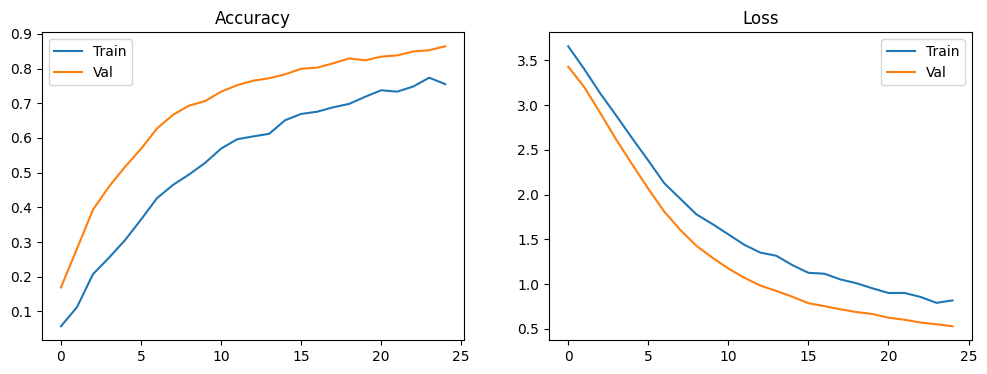

In [9]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train")
plt.plot(history.history["val_accuracy"], label="Val")
plt.title("Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train")
plt.plot(history.history["val_loss"], label="Val")
plt.title("Loss")
plt.legend()

plt.show()


In [10]:
fertilizer_dict = {
    "Cedar_apple_rust": "Apply balanced NPK fertilizer",
    "Black_rot": "Use potassium-rich fertilizer",
    "Yellow_Curl_Virus": "Reduce nitrogen",
    "Early_blight": "Apply compost & fungicide",
    "Late_blight": "Use phosphorus-rich fertilizer",
    "Healthy": "Use organic compost"
}

CONFIDENCE_THRESHOLD = 50.0


In [11]:
def predict_disease(image_path):
    img = load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = preprocess_input(np.expand_dims(img_to_array(img), axis=0))

    pred = model.predict(img_array, verbose=0)
    idx = np.argmax(pred)
    confidence = pred[0][idx] * 100
    label = class_labels[idx]

    if confidence < CONFIDENCE_THRESHOLD:
        return "Unknown", "Low Confidence", "Upload clear image", confidence

    if "___" in label:
        crop, disease = label.split("___")
        fertilizer = fertilizer_dict.get(disease, "General fertilizer")
    else:
        crop = label
        disease = "Healthy"
        fertilizer = fertilizer_dict["Healthy"]

    return crop, disease, fertilizer, confidence


In [13]:
CONFIDENCE_THRESHOLD = 50.0

def predict_disease(image_path, tta_runs=5):
    img = load_img(image_path, target_size=(IMG_SIZE, IMG_SIZE))
    img_array = img_to_array(img)

    predictions = []

    for _ in range(tta_runs):
        aug_img = preprocess_input(np.expand_dims(img_array, axis=0))
        pred = model.predict(aug_img, verbose=0)
        predictions.append(pred)

    avg_pred = np.mean(predictions, axis=0)

    idx = np.argmax(avg_pred)
    confidence = avg_pred[0][idx] * 100
    label = class_labels[idx]

    if confidence < CONFIDENCE_THRESHOLD:
        return "Unknown", "Low confidence", "Upload a clearer image", confidence

    if "___" in label:
        crop, disease = label.split("___")
        fertilizer = fertilizer_dict.get(disease, "General fertilizer")
    else:
        crop = label
        disease = "Healthy"
        fertilizer = fertilizer_dict.get("Healthy")

    return crop, disease, fertilizer, confidence


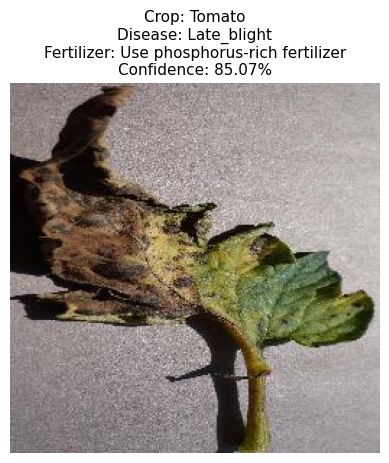

In [15]:
image_path = r"C:\Users\Dell\OneDrive\Desktop\plant_disease_dataset\test\test\TomatoEarlyBlight1.JPG"

crop, disease, fertilizer, confidence = predict_disease(image_path)

img = load_img(image_path)
plt.imshow(img)
plt.axis("off")

plt.title(
    f"Crop: {crop}\n"
    f"Disease: {disease}\n"
    f"Fertilizer: {fertilizer}\n"
    f"Confidence: {confidence:.2f}%",
    fontsize=11
)

plt.show()

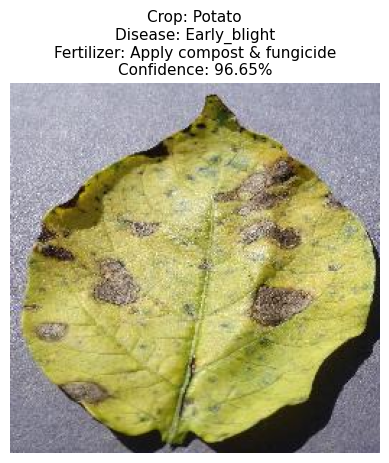

In [16]:
image_path = r"C:\Users\Dell\OneDrive\Desktop\plant_disease_dataset\test\test\PotatoEarlyBlight4.JPG"

crop, disease, fertilizer, confidence = predict_disease(image_path)

img = load_img(image_path)
plt.imshow(img)
plt.axis("off")

plt.title(
    f"Crop: {crop}\n"
    f"Disease: {disease}\n"
    f"Fertilizer: {fertilizer}\n"
    f"Confidence: {confidence:.2f}%",
    fontsize=11
)

plt.show()

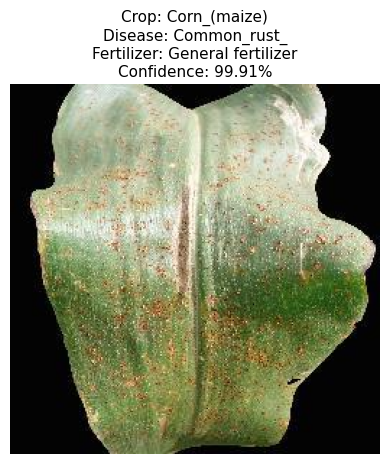

In [17]:
image_path = r"C:\Users\Dell\OneDrive\Desktop\plant_disease_dataset\test\test\CornCommonRust2.JPG"

crop, disease, fertilizer, confidence = predict_disease(image_path)

img = load_img(image_path)
plt.imshow(img)
plt.axis("off")

plt.title(
    f"Crop: {crop}\n"
    f"Disease: {disease}\n"
    f"Fertilizer: {fertilizer}\n"
    f"Confidence: {confidence:.2f}%",
    fontsize=11
)

plt.show()

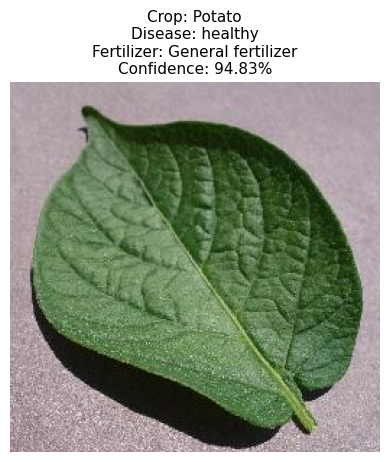

In [18]:
image_path = r"C:\Users\Dell\OneDrive\Desktop\plant_disease_dataset\test\test\PotatoHealthy1.JPG"

crop, disease, fertilizer, confidence = predict_disease(image_path)

img = load_img(image_path)
plt.imshow(img)
plt.axis("off")

plt.title(
    f"Crop: {crop}\n"
    f"Disease: {disease}\n"
    f"Fertilizer: {fertilizer}\n"
    f"Confidence: {confidence:.2f}%",
    fontsize=11
)

plt.show()

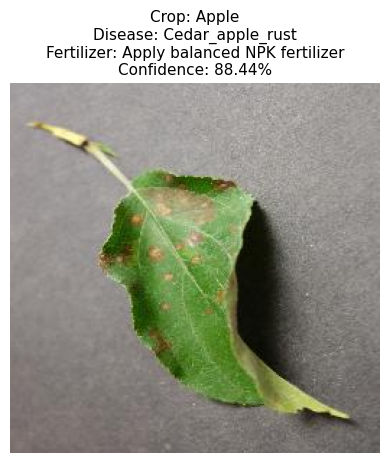

In [19]:
image_path = r"C:\Users\Dell\OneDrive\Desktop\plant_disease_dataset\test\test\AppleCedarRust3.JPG"

crop, disease, fertilizer, confidence = predict_disease(image_path)

img = load_img(image_path)
plt.imshow(img)
plt.axis("off")

plt.title(
    f"Crop: {crop}\n"
    f"Disease: {disease}\n"
    f"Fertilizer: {fertilizer}\n"
    f"Confidence: {confidence:.2f}%",
    fontsize=11
)

plt.show()